# ED Wait Time: Presentation Visuals
This notebook is for final presentation/report visuals only.

Prerequisites:
- Run notebooks/01_data_prep.ipynb
- Run notebooks/03_modeling_arrival_only.ipynb
- Run notebooks/04_modeling_retrospective.ipynb (optional but recommended)

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)

data_dir = Path('../data')
eda_path = data_dir / 'eda_df.csv'
eda_df = pd.read_csv(eda_path)

print('Loaded eda_df:', eda_df.shape)

Loaded eda_df: (121026, 36)


## 1) Wait Time Distribution

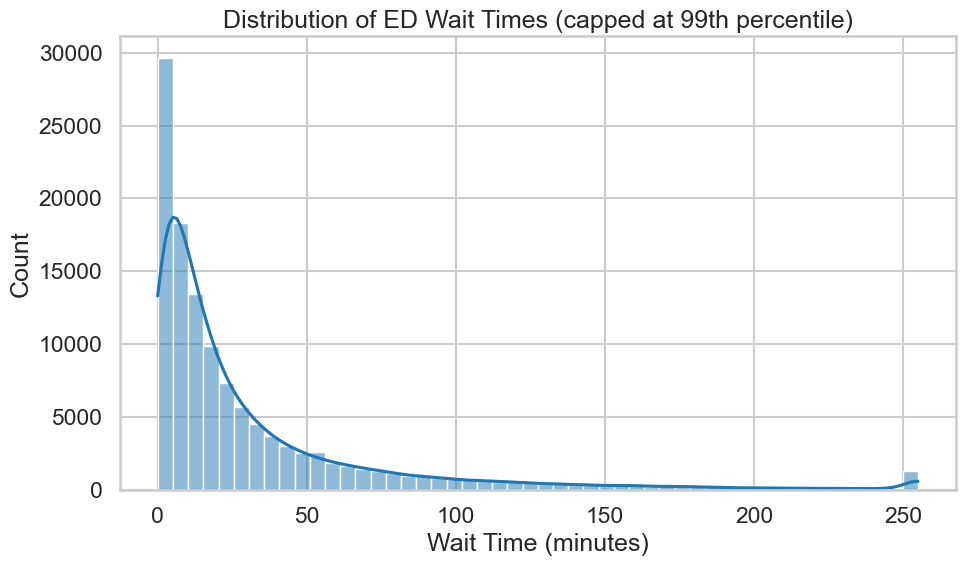

In [11]:
plot_df = eda_df.copy()
plot_df['WAITTIME'] = pd.to_numeric(plot_df['WAITTIME'], errors='coerce')
plot_df = plot_df[plot_df['WAITTIME'].notna()].copy()
cap = plot_df['WAITTIME'].quantile(0.99)
plot_df['WAITTIME_CAPPED'] = plot_df['WAITTIME'].clip(upper=cap)

plt.figure(figsize=(10, 6))
sns.histplot(plot_df['WAITTIME_CAPPED'], bins=50, kde=True, color='#1f77b4')
plt.title('Distribution of ED Wait Times (capped at 99th percentile)')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2) Wait Time by Arrival Hour

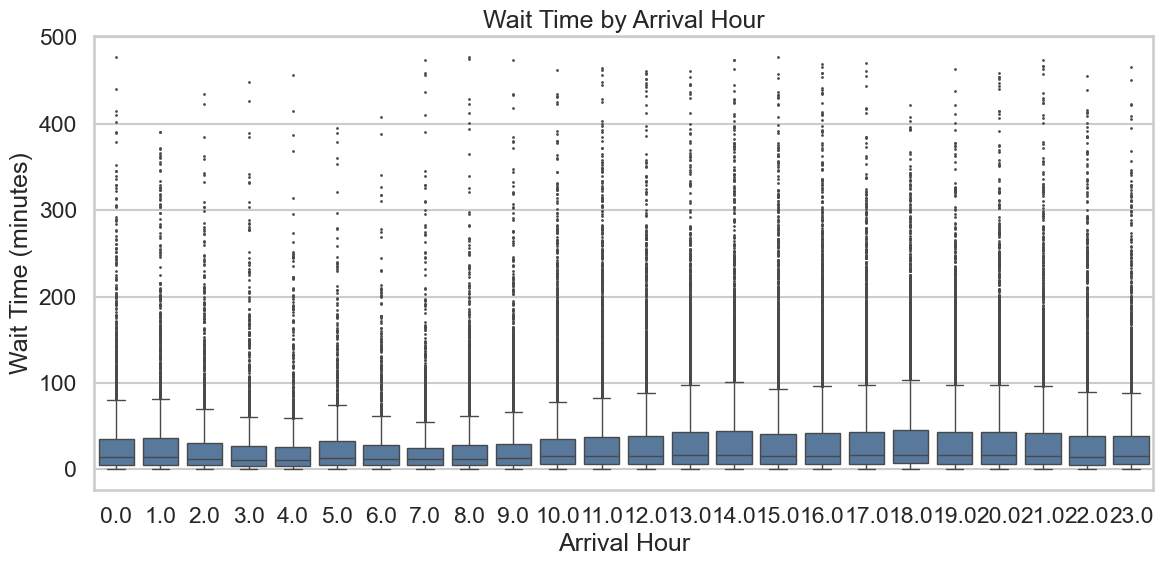

In [12]:
if {'ARRIVAL_HOUR', 'WAITTIME'}.issubset(plot_df.columns):
    hour_df = plot_df[['ARRIVAL_HOUR', 'WAITTIME']].copy()
    hour_df['ARRIVAL_HOUR'] = pd.to_numeric(hour_df['ARRIVAL_HOUR'], errors='coerce')
    hour_df = hour_df.dropna()

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=hour_df, x='ARRIVAL_HOUR', y='WAITTIME', color='#4c78a8', fliersize=1)
    plt.title('Wait Time by Arrival Hour')
    plt.xlabel('Arrival Hour')
    plt.ylabel('Wait Time (minutes)')
    plt.tight_layout()
    plt.show()

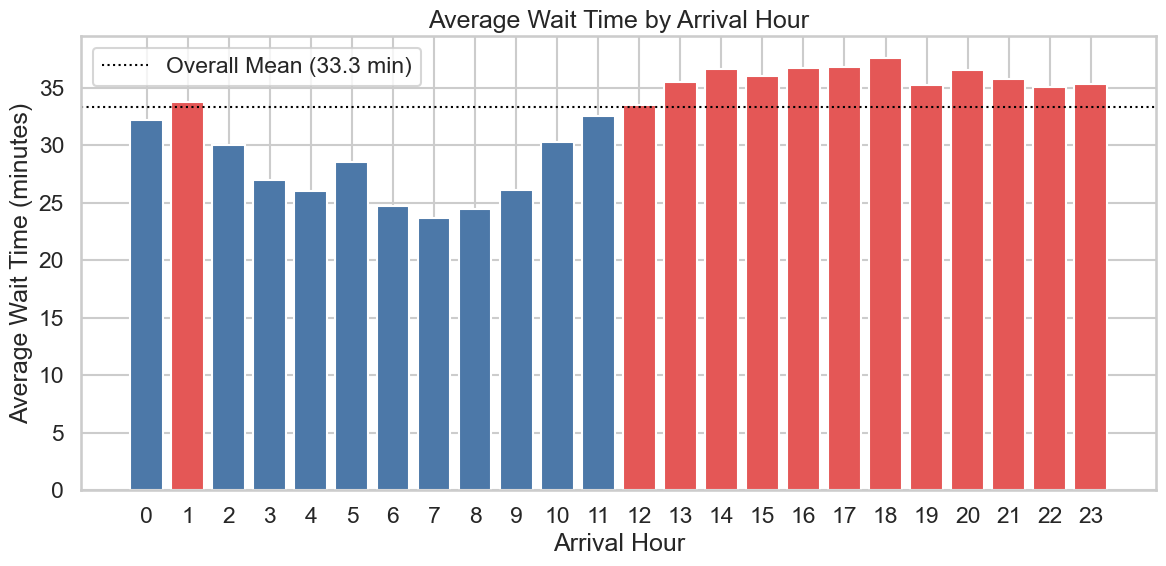

In [ ]:
#average wait time by arrival hour
#colored the bars based on whether they are above or below the overall mean wait time
if {'ARRIVAL_HOUR', 'WAITTIME'}.issubset(plot_df.columns):
    hour_avg = plot_df.groupby('ARRIVAL_HOUR', dropna=False)['WAITTIME'].mean().reset_index()
    hour_avg['ARRIVAL_HOUR'] = pd.to_numeric(hour_avg['ARRIVAL_HOUR'], errors='coerce')
    hour_avg = hour_avg.sort_values('ARRIVAL_HOUR')
    
    overall_mean = plot_df['WAITTIME'].mean()
    
    colors = ['#e45756' if m >= overall_mean else '#4c78a8' for m in hour_avg['WAITTIME']]
    
    plt.figure(figsize=(12, 6))
    plt.bar(hour_avg['ARRIVAL_HOUR'], hour_avg['WAITTIME'], color=colors, edgecolor='white')
    plt.axhline(y=overall_mean, color='black', linestyle=':', linewidth=1.5, label=f'Overall Mean ({overall_mean:.1f} min)')
    plt.title('Average Wait Time by Arrival Hour')
    plt.xlabel('Arrival Hour')
    plt.ylabel('Average Wait Time (minutes)')
    plt.xticks(range(0, 24))
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3) Wait Time by Triage (IMMEDR)

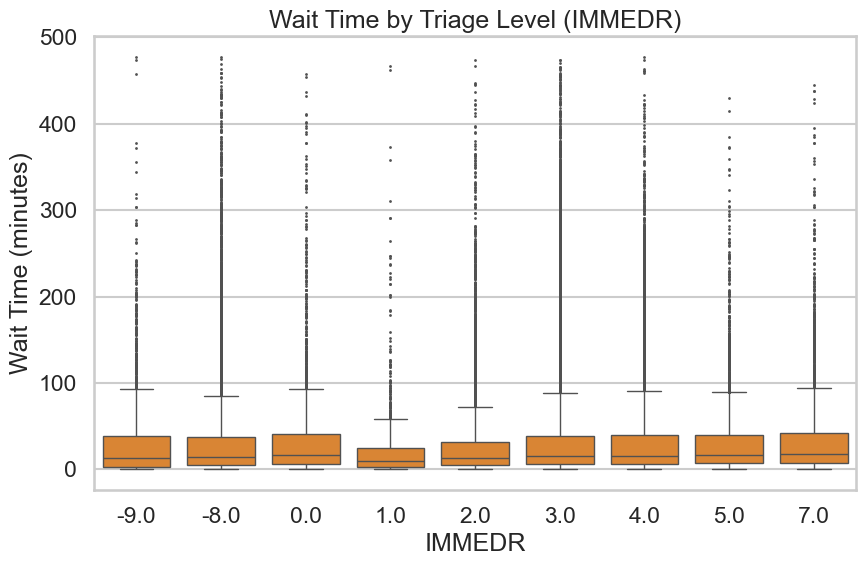

In [5]:
if {'IMMEDR', 'WAITTIME'}.issubset(plot_df.columns):
    triage_df = plot_df[['IMMEDR', 'WAITTIME']].copy()
    triage_df['IMMEDR'] = pd.to_numeric(triage_df['IMMEDR'], errors='coerce')
    triage_df = triage_df.dropna()

    plt.figure(figsize=(9, 6))
    sns.boxplot(data=triage_df, x='IMMEDR', y='WAITTIME', color='#f58518', fliersize=1)
    plt.title('Wait Time by Triage Level (IMMEDR)')
    plt.xlabel('IMMEDR')
    plt.ylabel('Wait Time (minutes)')
    plt.tight_layout()
    plt.show()

## 4) Day-of-Week Pattern

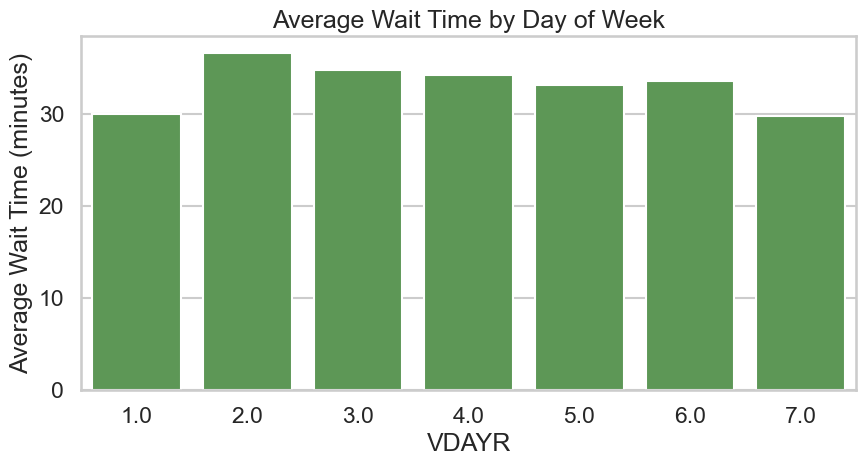

In [6]:
if {'VDAYR', 'WAITTIME'}.issubset(plot_df.columns):
    day_summary = plot_df.groupby('VDAYR', dropna=False)['WAITTIME'].mean().reset_index()
    day_summary['VDAYR'] = pd.to_numeric(day_summary['VDAYR'], errors='coerce')
    day_summary = day_summary.sort_values('VDAYR')

    plt.figure(figsize=(9, 5))
    sns.barplot(data=day_summary, x='VDAYR', y='WAITTIME', color='#54a24b')
    plt.title('Average Wait Time by Day of Week')
    plt.xlabel('VDAYR')
    plt.ylabel('Average Wait Time (minutes)')
    plt.tight_layout()
    plt.show()

## 5) Holdout Model Comparison

,model_name,split,mae,rmse,r2,source
3,residual_hgb,holdout,28.335195,55.911234,-0.097038,arrival_residual
2,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_residual
4,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_segmented
6,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,retrospective
5,segmented_hgb_by_immedr,holdout,28.361414,55.812886,-0.093182,arrival_segmented
7,linear_regression,holdout,34.486214,53.475413,-0.003533,retrospective


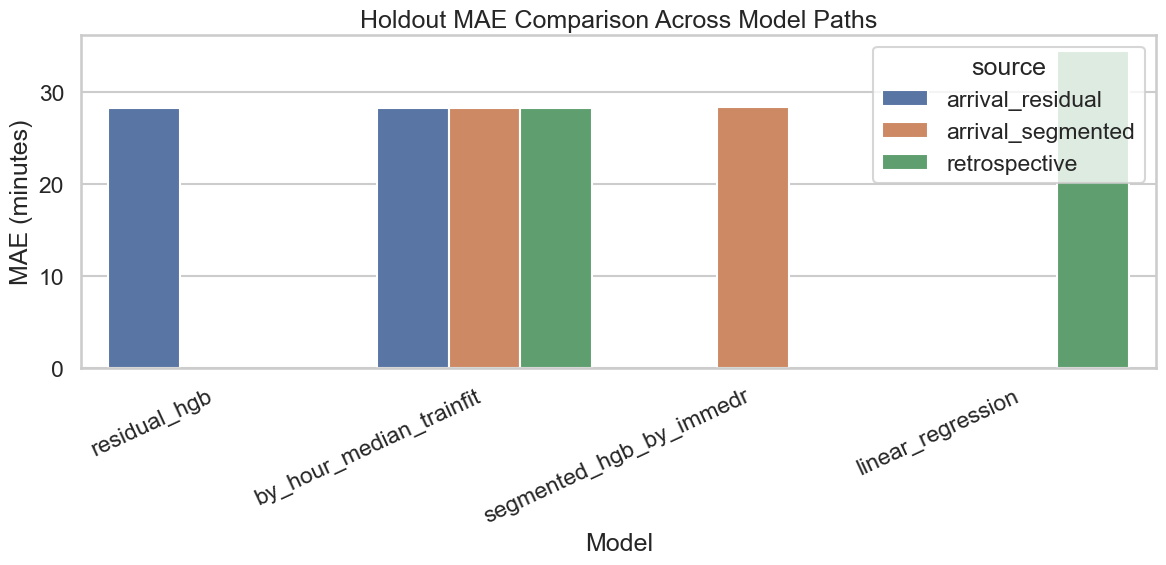

In [7]:
eval_files = {
    'arrival_residual': data_dir / 'model_eval_summary_improved.csv',
    'arrival_segmented': data_dir / 'model_eval_summary_segmented.csv',
    'retrospective': data_dir / 'model_eval_summary_retrospective.csv'
}

eval_frames = []
for source_name, file_path in eval_files.items():
    if file_path.exists():
        tmp = pd.read_csv(file_path)
        tmp['source'] = source_name
        eval_frames.append(tmp)

if not eval_frames:
    raise FileNotFoundError('No model evaluation files found in data/.')

all_eval = pd.concat(eval_frames, ignore_index=True)
holdout_eval = all_eval[all_eval['split'] == 'holdout'].copy()
holdout_eval = holdout_eval.sort_values('mae')

display(holdout_eval)

plt.figure(figsize=(12, 6))
sns.barplot(data=holdout_eval, x='model_name', y='mae', hue='source')
plt.title('Holdout MAE Comparison Across Model Paths')
plt.xlabel('Model')
plt.ylabel('MAE (minutes)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 6) Segmented Model Subgroup Impact

In [8]:
slice_path = data_dir / 'holdout_slice_report_segmented.csv'
if slice_path.exists():
    slice_df = pd.read_csv(slice_path)
    display(slice_df)

    if {'slice', 'mae_gain'}.issubset(slice_df.columns):
        plot_slice = slice_df.copy()
        if plot_slice.columns[1] != 'group_value':
            plot_slice = plot_slice.rename(columns={plot_slice.columns[1]: 'group_value'})

        plot_slice['label'] = plot_slice['slice'].astype(str) + ': ' + plot_slice['group_value'].astype(str)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=plot_slice, x='label', y='mae_gain', color='#e45756')
        plt.axhline(0, color='black', linewidth=1)
        plt.title('Segmented Model MAE Gain by Subgroup (positive is better)')
        plt.xlabel('Subgroup')
        plt.ylabel('MAE Gain vs Baseline')
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout()
        plt.show()

,segment,rows,mae_base,mae_segmented,mae_gain
0,high_acuity,1461,22.416838,22.394772,0.022066
1,other,11755,29.081667,29.102993,-0.021326


In [9]:
rank_path = data_dir / 'final_holdout_ranking.csv'
if 'holdout_eval' in globals() and not holdout_eval.empty:
    holdout_eval.to_csv(rank_path, index=False)
    print('Saved:', rank_path)

    best = holdout_eval.iloc[0]
    print('Best holdout model summary:')
    print(best[['model_name', 'source', 'mae', 'rmse', 'r2']])

Saved: ..\data\final_holdout_ranking.csv
Best holdout model summary:
model_name        residual_hgb
source        arrival_residual
mae                  28.335195
rmse                 55.911234
r2                   -0.097038
Name: 3, dtype: object
